CONTENTS:
- [Exploratory Data Analysis: Gridstatus metadata](#exploratory-data-analysis:-gridstatus-metadata)
    - [Missing Value Summary](#missing-value-summary)
      - [Exploring Gaps in Metadata Coverage](#exploring-gaps-in-metadata-coverage)
    - [Exploratory Analysis](#exploratory-analysis)
      - [Source Distribution](#source-distribution)
      - [Frequency Distribution](#frequency-distribution)
      - [Category Distribution](#category-distribution)
      - [How far the data goes back](#how-far-the-data-goes-back)
      - [Dataset Coverage Distribution](#dataset-coverage-distribution)
      - [Coverage Insights by Frequency and Snowflake Ingestion](#coverage-insights-by-frequency-and-snowflake-ingestion)
      - [Snowflake Ingestion Insights by Table Type](#snowflake-ingestion-insights-by-table-type)
      - [Analysis of Potentially Discontinued Series](#analysis-of-potentially-discontinued-series)
      - [Coverage by Source and Category](#coverage-by-source-and-category)

<a name='exploratory-data-analysis:-gridstatus-metadata'></a>
# Exploratory Data Analysis: Gridstatus metadata

This notebook analyzes the metadata of 268 time series datasets available on GridStatus.io. The metadata is loaded from the AWS S3 bucket `causify-data-collaborators` using helper functions from `hs3.py`. The goal is to explore the variety, coverage, and quality of the available time series data.

In [87]:
# Imports.
import io
import re

import helpers.hs3 as hs3
import IPython.display as disp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [88]:
# Load Data.
file_path = "s3://causify-data-collaborators/causal_automl/metadata/gridstatus_metadata.csv"
file = hs3.from_file(file_path, aws_profile="ck")
gs_meta = pd.read_csv(io.StringIO(file))

In [89]:
# Display structure of dataframe.
print(gs_meta.shape)
print(gs_meta.columns)
disp.display(gs_meta.head())

(268, 19)
Index(['id', 'name', 'description', 'earliest_available_time_utc',
       'latest_available_time_utc', 'source', 'last_checked_time_utc',
       'primary_key_columns', 'publish_time_column', 'time_index_column',
       'subseries_index_column', 'all_columns', 'number_of_rows_approximate',
       'table_type', 'is_in_snowflake', 'data_frequency', 'source_url',
       'publication_frequency', 'is_published'],
      dtype='object')


,id,name,description,earliest_available_time_utc,latest_available_time_utc,source,last_checked_time_utc,primary_key_columns,publish_time_column,time_index_column,subseries_index_column,all_columns,number_of_rows_approximate,table_type,is_in_snowflake,data_frequency,source_url,publication_frequency,is_published
0,all_records,All Records,Top daily records for various metrics across a...,2017-12-13T22:05:00+00:00,2025-03-26T15:30:00+00:00,gridstatus,2025-04-09T15:37:14+00:00,"['iso', 'rank', 'record_type', 'metric_name']",NaN,interval_start_utc,NaN,"[{'name': 'rank', 'type': 'BIGINT', 'is_numeri...",620,materialized_view,False,IRREGULAR,NaN,NaN,True
1,all_records_timeseries,All Records Timeseries,Timeline of new records for various metrics in...,2011-01-01T06:30:00+00:00,2025-03-25T00:40:00+00:00,gridstatus,2025-04-09T15:37:14+00:00,"['iso', 'interval_start_utc', 'record_type', '...",NaN,interval_start_utc,NaN,"[{'name': 'iso', 'type': 'TEXT', 'is_numeric':...",2076,materialized_view,False,IRREGULAR,NaN,NaN,True
2,caiso_as_prices,CAISO AS Prices,Ancillary Services Prices as reported by CAISO...,2010-01-01T08:00:00+00:00,2025-04-10T06:00:00+00:00,caiso,2025-04-09T15:37:12+00:00,"['interval_start_utc', 'region', 'market']",NaN,interval_start_utc,region,"[{'name': 'interval_start_utc', 'type': 'TIMES...",621445,table,True,1_HOUR,http://oasis.caiso.com/mrioasis/logon.do,NaN,True
3,caiso_as_procurement_dam,CAISO AS Procurement DAM,Ancillary services procurement data from CAISO...,2010-01-01T08:00:00+00:00,2025-04-10T06:00:00+00:00,caiso,2025-04-09T15:37:17+00:00,"['interval_start_utc', 'region']",NaN,interval_start_utc,region,"[{'name': 'interval_start_utc', 'type': 'TIMES...",623449,table,True,1_HOUR,http://oasis.caiso.com/mrioasis/logon.do,NaN,True
4,caiso_curtailed_non_operational_generator_report,CAISO Curtailed Non Operational Generator Report,Prior Day Curtailed Non-Operational Generator ...,2021-06-18T07:00:00+00:00,2025-04-09T07:00:00+00:00,caiso,2025-04-09T15:37:31+00:00,"['publish_time_utc', 'outage_mrid', 'curtailme...",publish_time_utc,curtailment_start_time_utc,NaN,"[{'name': 'publish_time_utc', 'type': 'TIMESTA...",2490715,table,True,IRREGULAR,https://www.caiso.com/market-operations/outage...,NaN,True


In [90]:
# Helper function to create plot.
def _make_plots(
    title=None,
    x_label=None,
    y_label=None,
    legend=None,
    x_rotation=None,
    y_rotation=None,
    grid=False,
) -> None:
    """
    Generate a plot with the given parameters.

    :param title: title of the plot
    :param x_label: x-axis label
    :param y_label: y-axis label
    :param legend: legend title
    :param x_rotation: rotation angle for x-axis labels
    :param y_rotation: rotation angle for y-axis labels
    :param grid: display grid if True
    """
    if title:
        plt.title(title)
    if x_label:
        plt.xlabel(x_label)
    if y_label:
        plt.ylabel(y_label)
    if legend:
        plt.legend(title=legend)
    if x_rotation is not None:
        plt.xticks(rotation=x_rotation)
    if y_rotation is not None:
        plt.yticks(rotation=y_rotation)
    if grid:
        plt.grid(grid)
    plt.show()


# Helper function to display percentage on bar plots.
def _display_percentage_plot(column) -> None:
    """
    Generate bar plot with percentage distribution.

    :param column: column to visualize as a percentage distribution
    """
    column_counts = gs_meta[column].value_counts()
    ax = column_counts.plot(kind="bar", figsize=(9, 5))
    for index, percentage in enumerate(column_counts / len(gs_meta) * 100):
        ax.text(
            index,
            column_counts.iloc[index],
            f"{percentage:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
        )

In [91]:
# Add a new category by parsing the description to match common categories.
category_keywords = [
    ("Energy", r"\b(load|energy)\b"),
    ("Renewables", r"\b(renewable|solar|wind|hydro)\b"),
    ("Non-renewables", r"\bnatural gas\b"),
    ("Fuel Mix", r"\bfuel\b"),
    ("Prices", r"\b(price|prices|pricing|spp|lmp)\b"),
    ("Power", r"\b(power|electric|outages)\b"),
    ("Emissions", r"\b(emission|emissions)\b"),
    ("Weather", r"\b(weather|temperature)\b"),
    ("Capacity", r"\b(capacity)\b"),
    ("Records", r"\b(record|records|statistics)\b"),
    ("Time Frequency", r"\b(day|daily|hour|hourly|minute|min)\b"),
]


def _categorize_metadata(name) -> str:
    """
    Categorize a dataset based on keywords in its name.

    :param name: name of the dataset
    :return: category label
    """
    name = str(name).lower()
    for category, keyword in category_keywords:
        # Match common keys to a known category.
        if re.search(keyword, name):
            return category
    return "Other"


gs_meta["category"] = gs_meta["name"].apply(_categorize_metadata)
disp.display(gs_meta.head())

,id,name,description,earliest_available_time_utc,latest_available_time_utc,source,last_checked_time_utc,primary_key_columns,publish_time_column,time_index_column,subseries_index_column,all_columns,number_of_rows_approximate,table_type,is_in_snowflake,data_frequency,source_url,publication_frequency,is_published,category
0,all_records,All Records,Top daily records for various metrics across a...,2017-12-13T22:05:00+00:00,2025-03-26T15:30:00+00:00,gridstatus,2025-04-09T15:37:14+00:00,"['iso', 'rank', 'record_type', 'metric_name']",NaN,interval_start_utc,NaN,"[{'name': 'rank', 'type': 'BIGINT', 'is_numeri...",620,materialized_view,False,IRREGULAR,NaN,NaN,True,Records
1,all_records_timeseries,All Records Timeseries,Timeline of new records for various metrics in...,2011-01-01T06:30:00+00:00,2025-03-25T00:40:00+00:00,gridstatus,2025-04-09T15:37:14+00:00,"['iso', 'interval_start_utc', 'record_type', '...",NaN,interval_start_utc,NaN,"[{'name': 'iso', 'type': 'TEXT', 'is_numeric':...",2076,materialized_view,False,IRREGULAR,NaN,NaN,True,Records
2,caiso_as_prices,CAISO AS Prices,Ancillary Services Prices as reported by CAISO...,2010-01-01T08:00:00+00:00,2025-04-10T06:00:00+00:00,caiso,2025-04-09T15:37:12+00:00,"['interval_start_utc', 'region', 'market']",NaN,interval_start_utc,region,"[{'name': 'interval_start_utc', 'type': 'TIMES...",621445,table,True,1_HOUR,http://oasis.caiso.com/mrioasis/logon.do,NaN,True,Prices
3,caiso_as_procurement_dam,CAISO AS Procurement DAM,Ancillary services procurement data from CAISO...,2010-01-01T08:00:00+00:00,2025-04-10T06:00:00+00:00,caiso,2025-04-09T15:37:17+00:00,"['interval_start_utc', 'region']",NaN,interval_start_utc,region,"[{'name': 'interval_start_utc', 'type': 'TIMES...",623449,table,True,1_HOUR,http://oasis.caiso.com/mrioasis/logon.do,NaN,True,Other
4,caiso_curtailed_non_operational_generator_report,CAISO Curtailed Non Operational Generator Report,Prior Day Curtailed Non-Operational Generator ...,2021-06-18T07:00:00+00:00,2025-04-09T07:00:00+00:00,caiso,2025-04-09T15:37:31+00:00,"['publish_time_utc', 'outage_mrid', 'curtailme...",publish_time_utc,curtailment_start_time_utc,NaN,"[{'name': 'publish_time_utc', 'type': 'TIMESTA...",2490715,table,True,IRREGULAR,https://www.caiso.com/market-operations/outage...,NaN,True,Other


<a name='missing-value-summary'></a>
### Missing Value Summary

The table below shows the number of missing (null) values in each metadata field, helping identify potential data quality issues.

In [93]:
# Display missing metadata statistics.
missing_count = gs_meta.isna().sum().sort_values(ascending=False)
missing_percent = (
    (gs_meta.isna().mean() * 100).sort_values(ascending=False).round(2)
)
missing_gs_meta = pd.DataFrame(
    {"Missing Count": missing_count, "Missing %": missing_percent}
)
missing_gs_meta = missing_gs_meta[missing_gs_meta["Missing Count"] > 0]
disp.display(missing_gs_meta)

,Missing Count,Missing %
publication_frequency,267,99.63
publish_time_column,198,73.88
subseries_index_column,161,60.07
source_url,37,13.81
earliest_available_time_utc,10,3.73
latest_available_time_utc,10,3.73
last_checked_time_utc,9,3.36
time_index_column,8,2.99
table_type,4,1.49
data_frequency,2,0.75


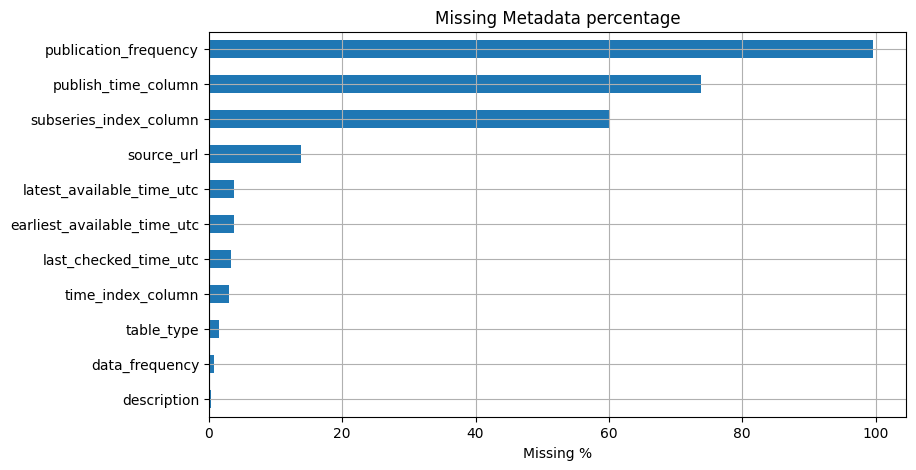

In [94]:
# Plot missing metadata statistics.
missing_gs_meta[missing_gs_meta["Missing Count"] > 0].sort_values(
    "Missing %", ascending=True
)["Missing %"].plot(
    kind="barh", figsize=(9, 5), title="Missing Metadata percentage"
)
_make_plots(x_label="Missing %", grid=True)

<a name='exploring-gaps-in-metadata-coverage'></a>
#### Exploring Gaps in Metadata Coverage

Metadata gaps usually happen because different datasets have different structures or ways of getting data. Understanding these gaps helps us evaluate how complete and reliable the dataset catalog is, ensuring that the metadata is useful for analysis and decision-making.

- Fields with the most gaps are publication_frequency (99.63%), publish_time_column (73.88%), subseries_index_column (60.07%). The large number of missing values probably means that these fields just do not apply to most datasets. The `NaN` values likely are not due to scraping issues, but rather that the data was not available in the first place. It is also possible that these columns were only added later, so older entries do not have them. This is confirmed by cross-checking these fields on the gridstatus website.

- Some source URLs (13.81%) may be missing, but since the `source` field still identifies the origin of the dataset, their absence does not significantly hinder metadata interpretation.

- The remaining fields have only a small number of missing values. This likely means that some data just genuinely does not exist or not available, so it is not necessarily a scraping issue. This is confirmed by cross-checking fields like earliest_available_time_utc, latest_available_time_utc, data_frequency and description.

<a name='exploratory-analysis'></a>
### Exploratory Analysis

From the 19 columns available in the GridStatus metadata, the following are most relevant for initial exploratory analysis:

- `source` : Identifies the origin of each dataset.
- `data_frequency` : Describes the granularity of data (e.g. 5 minutes, 1 hour, 1 day, etc).
- `is_in_snowflake` : Indicates whether the dataset is already ingested into the internal Snowflake warehouse.
- `table_type` : Helps categorize datasets by their structure or intended purpose (table, view, materialized view).
- `earliest_available_time_utc` : Indicates the starting point of data availability for each dataset.
- `latest_available_time_utc` : Indicates the most recent timestamp available in each dataset.


Several other metadata fields are available but were excluded from the initial analysis for the following reasons:

- Columns like `id`, `name`, and `description` are identifiers or unstructured text, making them unsuitable for analysis.
- Fields like `primary_key_columns`, `publish_time_column`, `subseries_index_column`, and `all_columns` are helpful for database structure but not very useful for analyzing overall metadata patterns.
- Fields like `last_checked_time_utc` are useful for monitoring and tracking system activity.
- `source_url` is a similar to `source`, as it includes a direct link to the data source, but it contains some null values and may not always be available.
- `number_of_rows_approximate` can be leveraged in future analytical processes to perform dataset size comparisons, enabling scalability assessments and optimization strategies.
- `time_index_column` indicates the name of the column containing timestamps, making it useful for dataset structure but not for actual time-based analysis.
- `is_published` is consistently `True` for all records (unless the metadata is updated) and therefore not relevant for analysis.
- `publication_frequency` is null for all records except one, and as a result, it is excluded from the analysis.

<a name='source-distribution'></a>
#### Source Distribution

Most of the datasets come from ERCOT, PJM, and CAISO, which are among the most active grid operators. Together, they account for over 50% of all datasets, showing a strong focus on these sources, possibly due to better data availability, higher reliability, or their overall importance in grid operations.

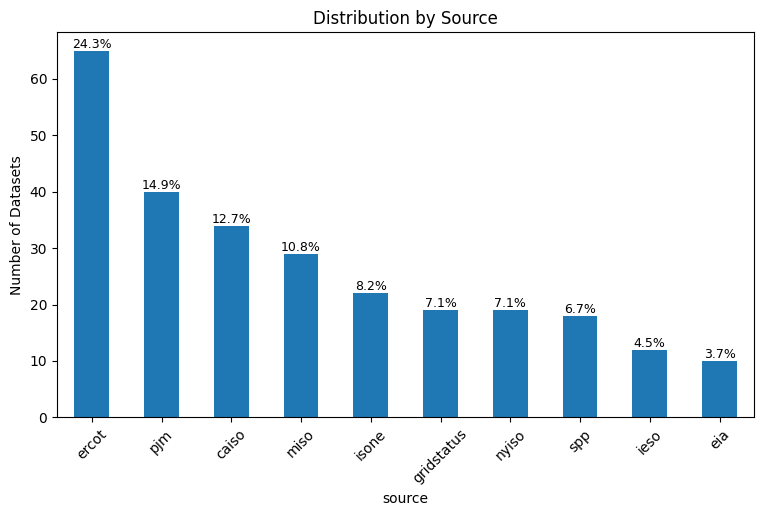

In [152]:
# Plot the distribution of entries by source from the dataframe.
_display_percentage_plot(column="source")
_make_plots(
    title="Distribution by Source", y_label="Number of Datasets", x_rotation=45
)

<a name='frequency-distribution'></a>
#### Frequency Distribution

Most of the datasets in GridStatus are updated frequently, with the majority (almost 75% of the dataset) being hourly or every 5 minutes. This suggests that the system is focused on providing up-to-date, real-time data, while fewer datasets cater to more specialized or less frequent data needs.

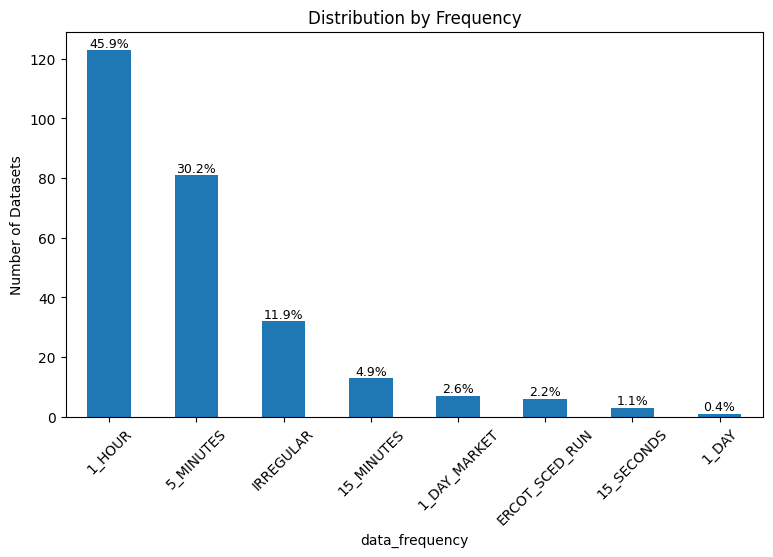

In [153]:
# Plot the distribution of entries by frequency from the dataframe.
_display_percentage_plot(column="data_frequency")
_make_plots(
    title="Distribution by Frequency", y_label="Number of Datasets", x_rotation=45
)

<a name='category-distribution'></a>
#### Category Distribution

Around 60% of the dataset fall under the category of Price, Energy and Time Frequency. Categories such as Capacity, Emissions, Non-renewables and Weather account to less than 3% of the dataset. Additionally, nearly 10% of the dataset does not fall under any defined category. This can be reduced by fine-tuning the categorization process, by using different parameters, such as description.

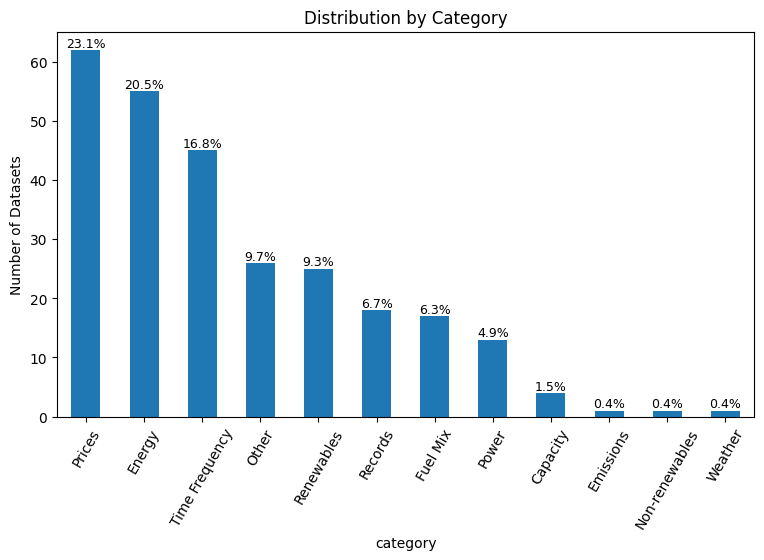

In [154]:
# Plot the distribution of entries by category from the dataframe.
_display_percentage_plot(column="category")
_make_plots(
    title="Distribution by Category", y_label="Number of Datasets", x_rotation=60
)

<a name='how-far-the-data-goes-back'></a>
#### How far the data goes back

The earliest available datasets indicate a few sources with historical data dating back to 1993 and the early 2000s, suggesting the presence of long-term historical records. However, the majority of datasets begin around 2010 or later, with a noticeable drop in availability after 2020. This gap could be attributed to several factors: a reduction in new data collection, shifts in collection focus, or the global impact of COVID-19, potentially disrupting data collection efforts during the pandemic. As organizations focused on the immediate needs of the crisis, some data streams may have been paused or limited.

In [155]:
# Convert timestamps to DateTime format.
gs_meta["earliest_available_time_utc"] = pd.to_datetime(
    gs_meta["earliest_available_time_utc"]
)
gs_meta["latest_available_time_utc"] = pd.to_datetime(
    gs_meta["latest_available_time_utc"]
)

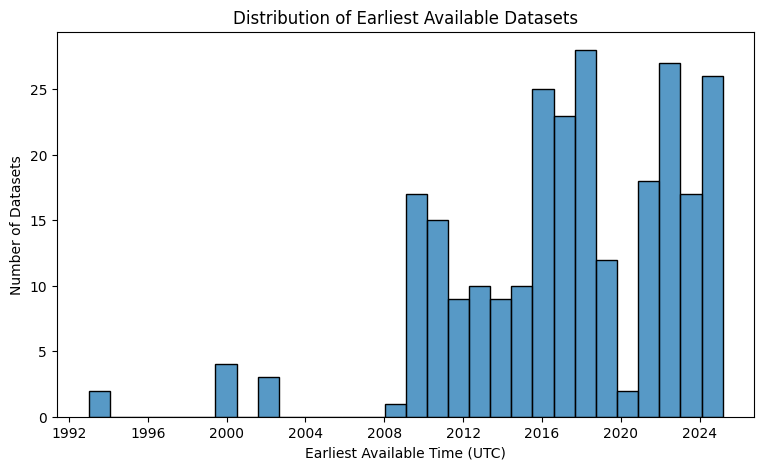

In [156]:
# Plot a histogram of the earliest available datasets.
plt.figure(figsize=(9, 5))
sns.histplot(gs_meta["earliest_available_time_utc"].dropna(), bins=30, kde=False)
_make_plots(
    title="Distribution of Earliest Available Datasets",
    x_label="Earliest Available Time (UTC)",
    y_label="Number of Datasets",
)

In [157]:
# Display the dataset(s) with the earliest available time.
earliest_rows = gs_meta[
    gs_meta["earliest_available_time_utc"]
    == gs_meta["earliest_available_time_utc"].min()
]
print("Earliest available dataset(s):")
disp.display(earliest_rows)

Earliest available dataset(s):


,id,name,description,earliest_available_time_utc,latest_available_time_utc,source,last_checked_time_utc,primary_key_columns,publish_time_column,time_index_column,...,number_of_rows_approximate,table_type,is_in_snowflake,data_frequency,source_url,publication_frequency,is_published,category,coverage,days_since_latest_data
222,pjm_load_metered_hourly,PJM Load Metered Hourly,The MWh net energy consumption by each service...,1993-01-01 05:00:00+00:00,2025-04-08 03:00:00+00:00,pjm,2025-04-09T15:38:01+00:00,"['interval_start_utc', 'mkt_region', 'zone', '...",NaN,interval_start_utc,...,5681485,table,True,1_HOUR,https://dataminer2.pjm.com/feed/hrl_load_meter...,NaN,True,Energy,32.262834,22.0


<a name='dataset-coverage-distribution'></a>
#### Dataset Coverage Distribution

The distribution of dataset coverage follows a clear multimodal pattern, with the Kernel Density Estimate (KDE) curve showing a concentration of datasets around 8-10 years, indicating that most datasets provide medium-term historical coverage. There is also a significant concentration around 3 years, reflecting a large number of more recent datasets. The curve shows a noticeable gap after 14-15 years, suggesting fewer datasets with coverage beyond this point. This pattern highlights the availability of datasets across various time spans, from recent data to long-term historical records, while pointing to a potential gap in coverage for datasets lasting beyond 15 years.

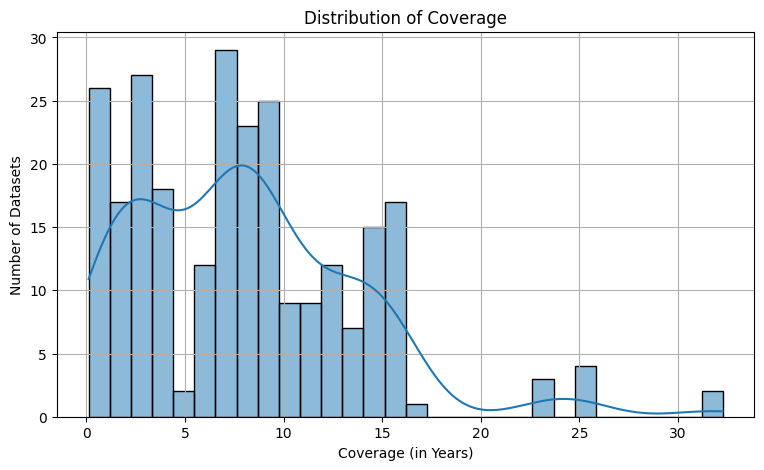

In [158]:
# Plot the distribution of dataset coverage with a Kernel Density Estimate (KDE) overlay.
gs_meta["coverage"] = (
    gs_meta["latest_available_time_utc"] - gs_meta["earliest_available_time_utc"]
).dt.days / 365.25
plt.figure(figsize=(9, 5))
sns.histplot(gs_meta["coverage"], bins=30, kde=True)
_make_plots(
    title="Distribution of Coverage",
    x_label="Coverage (in Years)",
    y_label="Number of Datasets",
    grid=True,
)

<a name='coverage-insights-by-frequency-and-snowflake-ingestion'></a>
#### Coverage Insights by Frequency and Snowflake Ingestion

The distribution of coverage durations across data frequencies reveals that the majority of datasets fall under the ‘1 hour’ and ‘5 mins’ categories (as shown in the previous graphs), reflecting a clear emphasis on high-resolution time series data. Notably, most of these high-frequency datasets are already ingested into Snowflake, suggesting that ingestion efforts are prioritized for data streams that support real-time or near-real-time analytics.

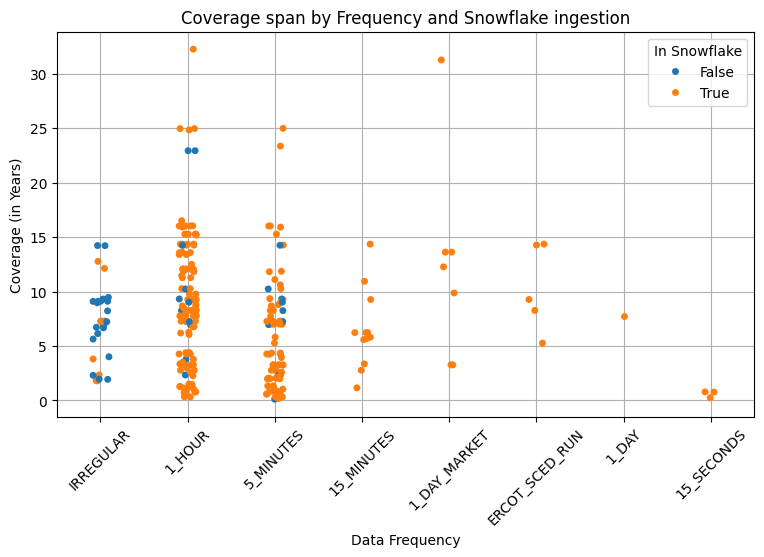

In [159]:
# Plot coverage span by data frequency, colored by Snowflake status.
plt.figure(figsize=(9, 5))
sns.stripplot(
    data=gs_meta,
    x="data_frequency",
    y="coverage",
    hue="is_in_snowflake",
    jitter=True,
)
_make_plots(
    title="Coverage span by Frequency and Snowflake ingestion",
    x_label="Data Frequency",
    y_label="Coverage (in Years)",
    legend="In Snowflake",
    x_rotation=45,
    grid=True,
)

<a name='snowflake-ingestion-insights-by-table-type'></a>
#### Snowflake Ingestion Insights by Table Type

```is_in_snowflake``` tells us what data is ready for the analytics team to use and what might still be missing from the system, while ```table_type``` distinguishes between how data is structured and consumed. Together, they highlight the current state of data integration and readiness across the warehouse. Understanding these gaps can inform ingestion priorities and surface potential blind spots in data accessibility.

The analysis of Snowflake ingestion shows some interesting patterns across different data types. All `materialized_view` entries and around 90% of `view` entries are not ingested into Snowflake. On the other hand, around 95% of `table_view` entries are successfully ingested into Snowflake, showing that most structured data is already in the system.

The limited Snowflake ingestion of `view` and `materialized_view` types may indicate that these datasets are not yet considered part of the core analytics workflow. The high ingestion rate of `table_view` entries could suggest a focus on integrating well-structured datasets into Snowflake. This shows possible gaps in the data pipeline and raises the question of whether configuring more `table_view` could better support analysis.

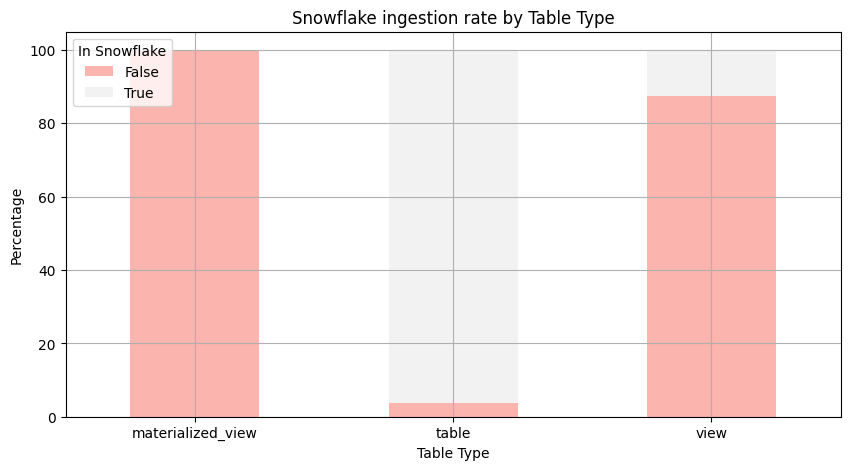

In [160]:
# Plot a normalized stacked bar chart of Snowflake ingestion by table type.
sf_by_ttype = (
    pd.crosstab(
        gs_meta["table_type"], gs_meta["is_in_snowflake"], normalize="index"
    )
    * 100
)
sf_by_ttype.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="Pastel1")
_make_plots(
    title="Snowflake ingestion rate by Table Type",
    x_label="Table Type",
    y_label="Percentage",
    legend="In Snowflake",
    x_rotation=0,
    grid=True,
)

<a name='analysis-of-potentially-discontinued-series'></a>
#### Analysis of Potentially Discontinued Series

This plot visualizes the number of time series grouped by the number of days since their most recent data point ```latest_available_time_utc```. Time series with a high number of days since the last update may indicate that the datasets are potentially discontinued or inactive. A threshold of 120 days has been set to flag series that are potentially outdated, helping to identify datasets that may require further review for reactivation, archival, or removal. This approach provides a proactive way to monitor the health and relevance of time series in the data pipeline.

In [161]:
gs_meta["days_since_latest_data"] = (
    pd.Timestamp.utcnow() - gs_meta["latest_available_time_utc"]
).dt.days
discontinued_threshold = 120
discontinued_data = gs_meta[
    gs_meta["days_since_latest_data"] > discontinued_threshold
]
display(discontinued_data)

,id,name,description,earliest_available_time_utc,latest_available_time_utc,source,last_checked_time_utc,primary_key_columns,publish_time_column,time_index_column,...,number_of_rows_approximate,table_type,is_in_snowflake,data_frequency,source_url,publication_frequency,is_published,category,coverage,days_since_latest_data
6,caiso_curtailment_aggregated_hourly,CAISO Curtailment Aggregated Hourly,CAISO curtailment aggregated by wind and solar...,2016-06-30 07:00:00+00:00,2023-09-29 01:00:00+00:00,caiso,NaN,['interval_start_utc'],NaN,interval_start_utc,...,-1,view,False,1_HOUR,https://www.caiso.com/about/our-business/manag...,NaN,True,Time Frequency,7.244353,579.0
106,ercot_spp_day_ahead_price_corrections,ERCOT SPP Day Ahead Price Corrections,ERCOT SPP Day Ahead Price Corrections,2012-03-07 22:45:00+00:00,2024-04-24 21:00:00+00:00,ercot,2025-04-09T15:01:08+00:00,"['location', 'interval_start_utc', 'price_corr...",price_correction_time_utc,interval_start_utc,...,1114520,table,True,IRREGULAR,https://www.ercot.com/mp/data-products/data-pr...,NaN,True,Prices,12.128679,370.0
108,ercot_spp_real_time_price_corrections,ERCOT SPP Real Time Price Corrections,ERCOT SPP Real Time Price Corrections,2012-02-27 20:37:06+00:00,2024-12-05 22:00:00+00:00,ercot,2025-04-09T15:01:12+00:00,"['location', 'interval_start_utc', 'price_corr...",price_correction_time_utc,interval_start_utc,...,562918,table,True,IRREGULAR,https://www.ercot.com/mp/data-products/data-pr...,NaN,True,Prices,12.772074,145.0
125,ieso_records_timeseries,IESO New Records Timeline,Timeline of new records for IESO,2015-01-01 22:00:00+00:00,2024-06-19 23:25:00+00:00,gridstatus,2025-04-09T15:36:27+00:00,"['interval_start_utc', 'record_type', 'metric_...",NaN,interval_start_utc,...,105,NaN,False,IRREGULAR,NaN,NaN,True,Records,9.464750,314.0


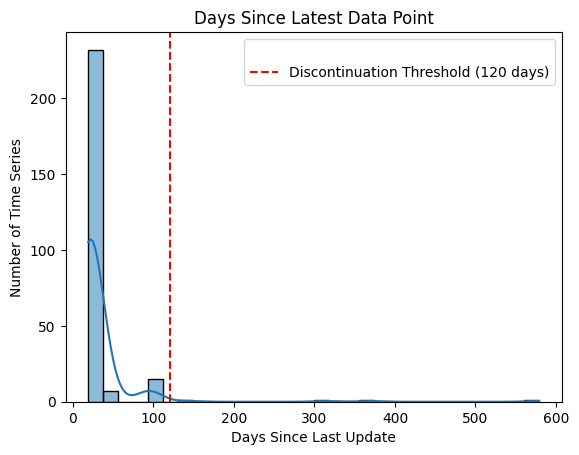

In [162]:
# Plot the distribution of days since the latest data point.
sns.histplot(gs_meta["days_since_latest_data"], bins=30, kde=True)
plt.axvline(
    discontinued_threshold,
    color="red",
    linestyle="--",
    label="Discontinuation Threshold (120 days)",
)
_make_plots(
    title="Days Since Latest Data Point",
    x_label="Days Since Last Update",
    y_label="Number of Time Series",
    legend=" ",
)

<a name='coverage-by-source-and-category'></a>
#### Coverage by Source and Category

The following heatmap shows the most popular categories across different data sources. ERCOT stands out with a wide range of categories, with Energy being the most popular among them. Across all sources, Prices category is the most frequently.

Categorization can be further fine-tuned using a larger number of records and more detailed metadata fields, such as descriptions, to have a better understanding of this coverage.

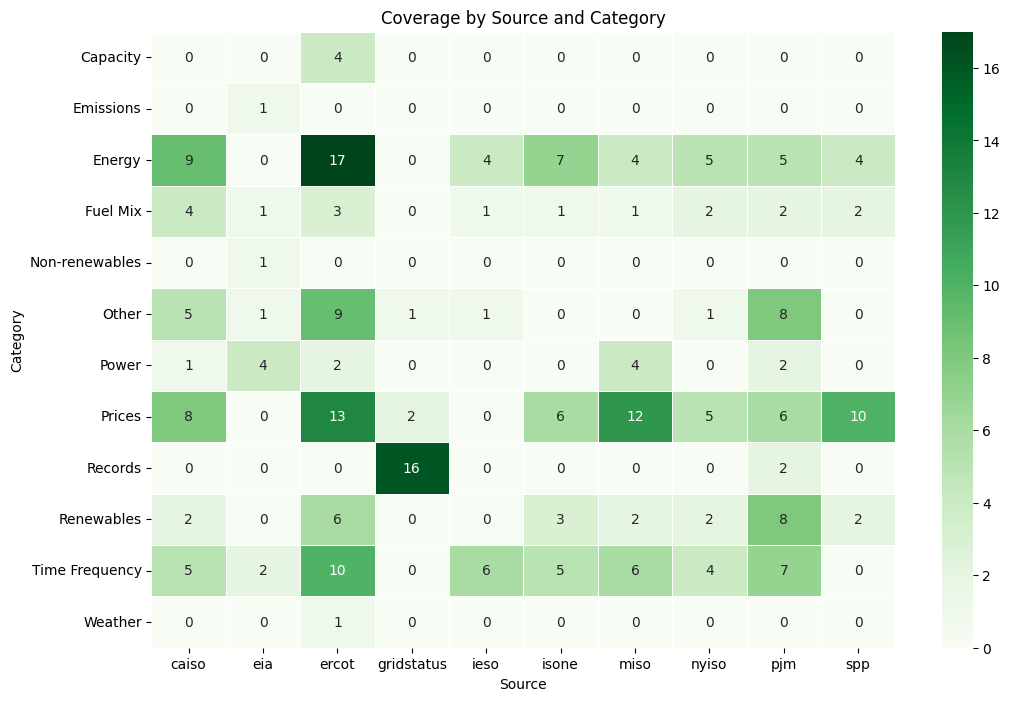

In [163]:
# Plot a heatmap to visualize the count of datasets across each source-category pair.
pivot_table = pd.pivot_table(
    gs_meta,
    values="id",
    index="category",
    columns="source",
    aggfunc="count",
    fill_value=0,
)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap="Greens", linewidths=0.5)
_make_plots(
    title="Coverage by Source and Category",
    x_label="Source",
    y_label="Category",
    y_rotation=0,
)